In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import time
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock

# Lock for thread-safe printing
print_lock = Lock()

def get_lightcurve_info(row_data):
    """Get sector info for a single TIC - designed for parallel processing"""
    i, tic_id, st_tmag, st_rad, st_mass, st_teff = row_data
    tic = f"TIC {int(tic_id)}"
    
    try:
        lc_collection = lk.search_lightcurve(tic, mission="TESS", author="TESS-SPOC", cadence="long").mission
        if lc_collection is not None:
            sector_length = len(lc_collection)
            with print_lock:
                print(f'{i} tic {tic}: sector length {sector_length}, tmag {st_tmag}, rad {st_rad}, mass {st_mass}, teff {st_teff}')
                
            return {
                'tic': tic,
                'sector_length': sector_length,
                'st_tmag': st_tmag,
                'st_rad': st_rad,
                'st_mass': st_mass,
                'st_teff': st_teff
            }
        else:
            with print_lock:
                print(f'{i} tic {tic}: No data found')
            return {
                'tic': tic,
                'sector_length': np.nan,
                'st_tmag': st_tmag,
                'st_rad': st_rad,
                'st_mass': st_mass,
                'st_teff': st_teff
            }
    except Exception as e:
        with print_lock:
            print(f"Error processing {tic}: {e}")
        return {
            'tic': tic,
            'sector_length': np.nan,
            'st_tmag': st_tmag,
            'st_rad': st_rad,
            'st_mass': st_mass,
            'st_teff': st_teff
        }

# Load and deduplicate data
star_params = pd.read_csv("matched_CTL_sample_with_properties_10x.csv")
star_params = star_params[star_params['tmag'] < 13]
star_params = star_params[star_params['teff'] > 3000]
star_params = star_params[star_params['teff'] < 7000]
#print(star_params)
#print(f"Max st_teff: {star_params['st_teff'].max()}")
star_params = star_params#[2900000:2930000]  # Process only first 100 rows for testing
print(f"Original rows: {len(star_params)}")

# Remove duplicates based on TIC ID - keep first occurrence
star_params_unique = star_params.drop_duplicates(subset=['tic_id'], keep='first').reset_index(drop=True)
print(f"After deduplication: {len(star_params_unique)}")
print(f"Duplicates removed: {len(star_params) - len(star_params_unique)}\n")

# Load existing results to skip already processed TICs
output_file = "CTL_10x_with_sectors.csv"
if os.path.exists(output_file):
    existing_results = pd.read_csv(output_file)
    processed_tics = set(existing_results['tic'].values)
    print(f"Found {len(processed_tics)} already processed TICs\n")
else:
    existing_results = pd.DataFrame()
    processed_tics = set()

# Start timing
start_time = time.time()
print(f"Starting processing at {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total stars to process: {len(star_params_unique)}\n")

# Prepare data for parallel processing - skip already processed TICs
row_data_list = [
    (i, row['tic_id'], row['tmag'], row['radius'], row['mst'], row['teff'])
    for i, row in star_params_unique.iterrows()
    if f"TIC {int(row['tic_id'])}" not in processed_tics
]

print(f"Skipping {len(star_params_unique) - len(row_data_list)} already processed TICs")
print(f"Processing {len(row_data_list)} new TICs\n")

# Parallel processing with ThreadPoolExecutor
# Use max_workers based on your system - typically 10-20 for I/O-bound tasks
max_workers = 10  # Adjust this based on your system and network bandwidth
results_list = []

print(f"Using {max_workers} parallel workers\n")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Submit all tasks
    future_to_row = {executor.submit(get_lightcurve_info, row_data): row_data for row_data in row_data_list}
    
    # Collect results as they complete
    completed = 0
    for future in as_completed(future_to_row):
        result = future.result()
        results_list.append(result)
        completed += 1
        
        # Progress update every 10 stars
        if completed % 10 == 0:
            elapsed = time.time() - start_time
            rate = completed / elapsed
            remaining = len(row_data_list) - completed
            eta = remaining / rate if rate > 0 else 0
            with print_lock:
                print(f"\nProgress: {completed}/{len(row_data_list)} ({100*completed/len(row_data_list):.1f}%) - ETA: {eta/60:.1f} min\n")

# Combine new results with existing ones
if len(results_list) > 0:
    CTL_sectors = pd.concat([existing_results, pd.DataFrame(results_list)], ignore_index=True)
    CTL_sectors.to_csv(output_file, index=False)
    print(f"\nSaved {len(results_list)} new results ({len(CTL_sectors)} total) to {output_file}")
else:
    CTL_sectors = existing_results
    print(f"\nNo new results to save")

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"Total time elapsed: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
if len(row_data_list) > 0:
    print(f"Average time per star: {elapsed_time/len(row_data_list):.2f} seconds")
    print(f"Processing rate: {len(row_data_list)/elapsed_time:.2f} stars/second")
print(f"Finished at {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*60}")

Original rows: 11525
After deduplication: 11504
Duplicates removed: 21

Starting processing at 2025-11-03 12:08:25
Total stars to process: 11504

Skipping 0 already processed TICs
Processing 11504 new TICs

Using 10 parallel workers

8 tic TIC 359185852: sector length 2, tmag 11.2089, rad 0.20511501, mass 0.17407501, teff 3143.0
5 tic TIC 447382925: sector length 2, tmag 11.3234, rad 0.20576, mass 0.17471901, teff 3249.0
2 tic TIC 206402318: sector length 4, tmag 11.4104, rad 0.183439, mass 0.15295, teff 3125.0
9 tic TIC 437041669: sector length 3, tmag 11.3586, rad 0.18222301, mass 0.151795, teff 3078.0
3 tic TIC 207339173: sector length 6, tmag 11.4357, rad 0.196289, mass 0.16534901, teff 3152.0
1 tic TIC 284701226: sector length 4, tmag 11.2282, rad 0.207306, mass 0.176267, teff 3277.0
4 tic TIC 16530308: sector length 1, tmag 11.1683, rad 0.213781, mass 0.182804, teff 3248.0
6 tic TIC 92994182: sector length 2, tmag 11.5236, rad 0.212017, mass 0.181014, teff 3159.0
10 tic TIC 28831

No data found for target "TIC 287291938".


50 tic TIC 332799564: sector length 2, tmag 10.7681, rad 0.28272599, mass 0.257036, teff 3202.0
Error processing TIC 287291938: 'mission'
51 tic TIC 241217645: sector length 0, tmag 10.4533, rad 0.28000501, mass 0.25397801, teff 3367.0
52 tic TIC 100800733: sector length 0, tmag 10.5752, rad 0.322052, mass 0.30192199, teff 3415.0

Progress: 50/11504 (0.4%) - ETA: 105.2 min

41 tic TIC 72766563: sector length 4, tmag 12.7921, rad 0.25959101, mass 0.23131201, teff 3253.0
55 tic TIC 345606860: sector length 2, tmag 10.7786, rad 0.30507401, mass 0.28241399, teff 3254.0
56 tic TIC 351346161: sector length 1, tmag 10.722, rad 0.30339301, mass 0.28049201, teff 3253.0
58 tic TIC 165204611: sector length 4, tmag 10.4559, rad 0.27699801, mass 0.250608, teff 3243.0
54 tic TIC 464515919: sector length 1, tmag 10.4974, rad 0.31287, mass 0.29135299, teff 3321.0
57 tic TIC 123013596: sector length 5, tmag 10.491, rad 0.29732099, mass 0.27356401, teff 3311.0
60 tic TIC 403956193: sector length 3, tmag

No data found for target "TIC 329574121".


45 tic TIC 76349247: sector length 4, tmag 9.5436602, rad 0.317004, mass 0.29610699, teff 3412.0
Error processing TIC 329574121: 'mission'

Progress: 60/11504 (0.5%) - ETA: 100.9 min

59 tic TIC 135232258: sector length 3, tmag 10.5199, rad 0.29742301, mass 0.27368, teff 3379.0
66 tic TIC 186533446: sector length 1, tmag 11.4495, rad 0.27573901, mass 0.249199, teff 3569.0
64 tic TIC 229142295: sector length 4, tmag 11.1831, rad 0.26661399, mass 0.23905, teff 3131.0
62 tic TIC 300834678: sector length 3, tmag 11.4429, rad 0.314706, mass 0.293464, teff 3450.0
69 tic TIC 437063338: sector length 0, tmag 11.2959, rad 0.29089299, mass 0.26626101, teff 3275.0
68 tic TIC 306123710: sector length 1, tmag 11.1961, rad 0.280287, mass 0.25429499, teff 3245.0
67 tic TIC 406757212: sector length 2, tmag 11.5242, rad 0.294806, mass 0.270702, teff 3363.0
70 tic TIC 455280915: sector length 4, tmag 11.6616, rad 0.32232499, mass 0.30223599, teff 3300.0
63 tic TIC 10660045: sector length 0, tmag 11.4105

...

Error processing TIC 371792676: 'mission'
11441 tic TIC 389643975: sector length 1, tmag 9.4897003, rad 1.92879, mass 0.95999998, teff 5482.1499
11408 tic TIC 41030435: sector length 12, tmag 9.2194004, rad 2.0653501, mass nan, teff 6242.7998
11443 tic TIC 301351223: sector length 3, tmag 9.6639996, rad 2.05832, mass 1.37, teff 6583.0
11445 tic TIC 210869415: sector length 2, tmag 9.6471996, rad 2.1441, mass 1.2, teff 6225.0
11444 tic TIC 104035377: sector length 1, tmag 9.6399899, rad 2.00705, mass 0.99900001, teff 5637.0
11448 tic TIC 159884292: sector length 1, tmag 9.4565001, rad 2.0499101, mass 1.28, teff 6399.0
11447 tic TIC 459969792: sector length 6, tmag 9.4563904, rad 2.2502799, mass 1.283, teff 6398.0
11450 tic TIC 371059671: sector length 0, tmag 9.3532305, rad 2.0245199, mass 1.442, teff 6748.0
11451 tic TIC 328180847: sector length 2, tmag 9.559, rad 1.90643, mass 1.42, teff 6703.0

Progress: 11450/11504 (99.5%) - ETA: 0.5 min

11452 tic TIC 427999044: sector length 1, tm

No data found for target "TIC 272206410".


11474 tic TIC 87203821: sector length 3, tmag 8.4018402, rad 2.34284, mass 1.393, teff 6635.0
Error processing TIC 272206410: 'mission'
11485 tic TIC 466383250: sector length 1, tmag 9.2038202, rad 2.4356301, mass 1.237, teff 6301.3101
11484 tic TIC 171601691: sector length 2, tmag 9.0421, rad 2.5972199, mass 1.26, teff 6351.77
11475 tic TIC 66581710: sector length 3, tmag 8.4628, rad 2.5214601, mass 1.1900001, teff 6199.0
11478 tic TIC 55925436: sector length 1, tmag 9.2334003, rad 2.5023, mass 1.15, teff 6113.0
11486 tic TIC 416449791: sector length 10, tmag 9.1834002, rad 2.4572899, mass 1.27, teff 6381.0
11488 tic TIC 162676104: sector length 5, tmag 9.45294, rad 2.51127, mass 1.007, teff 5668.9902
11487 tic TIC 385229463: sector length 2, tmag 9.5746498, rad 2.60163, mass 1.0420001, teff 5799.3501
11490 tic TIC 103685646: sector length 6, tmag 9.6724005, rad 2.3951399, mass 1.45, teff 6760.0

Progress: 11490/11504 (99.9%) - ETA: 0.1 min

11491 tic TIC 191665569: sector length 1, t

No data found for target "TIC 455008534".


Error processing TIC 455008534: 'mission'
11496 tic TIC 318558834: sector length 1, tmag 8.94662, rad 3.16347, mass 1.11, teff 6008.0
11501 tic TIC 150593128: sector length 0, tmag 7.9829001, rad 4.2720699, mass 1.38, teff 6599.0
11498 tic TIC 330777218: sector length 1, tmag 8.7572699, rad 3.0415001, mass 1.169, teff 6153.0
11497 tic TIC 108590480: sector length 1, tmag 8.6416998, rad 3.12573, mass 1.47, teff 6808.0
11489 tic TIC 45313434: sector length 3, tmag 9.5109997, rad 2.33167, mass 1.34, teff 6519.2798
11503 tic TIC 83795958: sector length 3, tmag 8.5650196, rad 4.53512, mass 1.426, teff 6710.0
11500 tic TIC 451299978: sector length 2, tmag 8.184, rad 4.1679201, mass 1.48, teff 6846.0

Progress: 11500/11504 (100.0%) - ETA: 0.0 min

11502 tic TIC 337025463: sector length 2, tmag 8.4766998, rad 4.16048, mass 1.5, teff 6906.4702

Saved 11504 new results (11504 total) to CTL_10x_with_sectors.csv

Processing complete!
Total time elapsed: 6125.95 seconds (102.10 minutes)
Average tim

number of tics with sectors: 9976


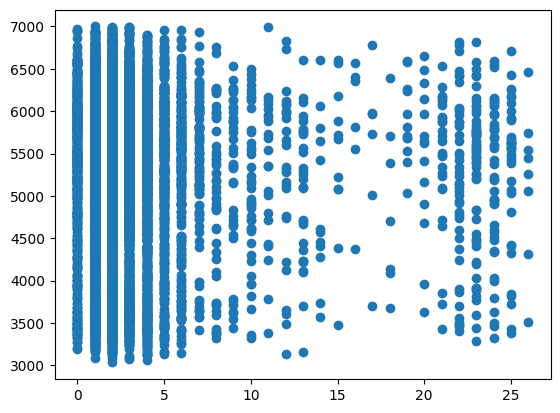

(array([ 434., 2410., 3540., 1418.,  938.,  401.,  233.,    0.,   99.,
          52.,   40.,   42.,   22.,   27.,    0.,   29.,   12.,   11.,
           6.,    6.,    7.,   12.,    0.,   14.,   27.,   44.,   60.,
          47.,   37.,    8.]),
 array([ 0.        ,  0.86666667,  1.73333333,  2.6       ,  3.46666667,
         4.33333333,  5.2       ,  6.06666667,  6.93333333,  7.8       ,
         8.66666667,  9.53333333, 10.4       , 11.26666667, 12.13333333,
        13.        , 13.86666667, 14.73333333, 15.6       , 16.46666667,
        17.33333333, 18.2       , 19.06666667, 19.93333333, 20.8       ,
        21.66666667, 22.53333333, 23.4       , 24.26666667, 25.13333333,
        26.        ]),
 <BarContainer object of 30 artists>)

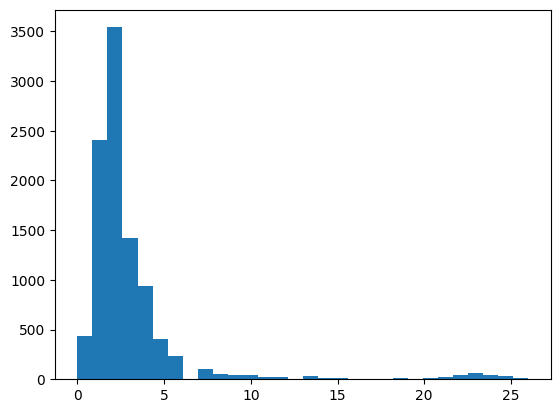

In [2]:
import matplotlib.pyplot as plt
print('number of tics with sectors:', CTL_sectors['sector_length'].notnull().sum())
plt.plot(CTL_sectors['sector_length'], CTL_sectors['st_teff'],marker='o', linestyle='None')
plt.show()

plt.hist(CTL_sectors['sector_length'].dropna(), bins=30)

# Convert npz to csv
Add sector count column to the CTL catalog

In [ ]:
# Load CTL_2025April29.npz and convert to CSV - properly combine all columns
import numpy as np
import pandas as pd
import os

print("=== Loading CTL_2025April29.npz ===")
print(f"File size: {os.path.getsize('CTL_2025April29.npz')/1e6:.2f} MB\n")

# Load the .npz file
ctl_data = np.load("CTL_2025April29.npz", allow_pickle=True)

print(f"Keys in file: {list(ctl_data.files)}")
print(f"Number of columns: {len(ctl_data.files)}\n")

# Build DataFrame by loading each column
data_dict = {}
for key in ctl_data.files:
    data_dict[key] = ctl_data[key]
    print(f"  '{key}': {len(ctl_data[key])} values, dtype: {ctl_data[key].dtype}")

# Create DataFrame from all columns
ctl_df = pd.DataFrame(data_dict)

print(f"\n{'='*60}")
print(f"DataFrame shape: {ctl_df.shape}")
print(f"Columns ({len(ctl_df.columns)}): {list(ctl_df.columns)}")
print(f"\nFirst 5 rows:")
print(ctl_df.head(5))
print(f"\nData types:")
print(ctl_df.dtypes)
print(f"\nBasic statistics:")
print(ctl_df.describe())

# Save to CSV
output_filename = "CTL_2025April29.csv"
ctl_df.to_csv(output_filename, index=False)
print(f"\n✅ Saved {len(ctl_df):,} rows × {len(ctl_df.columns)} columns to {output_filename}")
print(f"   File size: {os.path.getsize(output_filename)/1e6:.2f} MB")


In [ ]:
# Diagnostic: Identify TIC column
print(f"Total columns: {len(ctl_df.columns)}\n")

# Look for TIC-related columns
tic_candidates = [col for col in ctl_df.columns if 'tic' in str(col).lower() or 'id' in str(col).lower()]
print(f"TIC candidates: {tic_candidates}\n")

# Show all columns with sample data
print("All columns with samples:")
for i, col in enumerate(ctl_df.columns[:20]):  # First 20 columns
    sample = ctl_df[col].iloc[:3].tolist()
    print(f"  [{i}] '{col}' ({ctl_df[col].dtype}): {sample}")

# If numeric column 0 exists, it might be the TIC IDs
if 0 in ctl_df.columns:
    print(f"\nColumn 0 appears to exist - sample values: {ctl_df[0].iloc[:5].tolist()}")
    print(f"This might be TIC IDs if they look like large integers")